# Riduzione del Dettaglio delle Mappe delle Zone di Consegna per Dashboard Logistiche Veloci con PROC GREDUCE

## Riepilogo Esecutivo

Un corriere regionale di pacchi memorizza i confini del proprio territorio di servizio come contorni poligonali densi, e le dashboard di pianificazione dei percorsi li ridisegnano lentamente. Questo notebook sintetizza le coordinate di confine per quattro zone di consegna, usa **PROC GREDUCE** per etichettare ogni vertice di confine con un livello `DENSITY`, poi genera una mappa coropletica della consegna puntuale con **PROC GMAP** a un livello di dettaglio ridotto in modo che la mappa si disegni più velocemente mentre ogni zona resta riconoscibile.

GREDUCE ha classificato i 96 punti di confine in tre livelli: 10 punti a `DENSITY=0`, 44 a `DENSITY=2` e 42 a `DENSITY=3`. Mantenere solo il livello grossolano (`DENSITY <= 2`) riduce la mappa da 96 a 54 vertici — circa una riduzione del 44% — eppure le quattro zone restano chiaramente identificabili nel confronto affiancato qui sotto.

## Fonti dei Dati

Tutti i dati sono generati in linea dai passi DATA seguenti — nessun file esterno o accesso di rete.

| Dataset | Righe | Variabili chiave | Descrizione |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zone x 24 vertici) | `zone` (ID), `x`, `y` | Coordinate sintetiche di confine a poligono chiuso per quattro zone di servizio di consegna, ciascuna un'ellisse con jitter tracciata da 24 vertici in modo che la riduzione della densità abbia qualcosa da assottigliare. |
| `reducedmap` | 96 | aggiunge `density` | Output di PROC GREDUCE: i punti di confine etichettati con un livello `DENSITY` (qui 0, 2 o 3) per il rendering selettivo. |
| `coarsemap` | 54 | sottoinsieme di `reducedmap` | Il sottoinsieme `DENSITY <= 2` — il livello grossolano a rendering veloce usato per la mappa dashboard a dettaglio ridotto. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Una riga di risposta per zona: percentuale sintetica di consegna puntuale e volume giornaliero di pacchi, unita alla mappa per la coropletica. |

> **Nota sulla dimensione del campione.** Questo ambiente gira senza licenza, quindi ogni passo DATA è limitato a 100 osservazioni in output. La mappa è dimensionata a 4 zone x 24 vertici = 96 punti in modo che l'intero territorio rientri in quel limite; un'installazione con licenza traccerebbe centinaia di vertici per zona, dove GREDUCE rende ancora di più.

# Riduzione del Dettaglio delle Mappe delle Zone di Consegna con PROC GREDUCE

Gli operatori logistici visualizzano le prestazioni su mappe dei loro **territori di servizio** — le zone geografiche di cui un deposito è responsabile. Quei confini di zona sono spesso acquisiti a risoluzione di rilievo: molti vertici per poligono. Quando una dashboard di pianificazione dei percorsi ridisegna più zone contemporaneamente, tutto quel dettaglio di vertici rende il rendering lento senza aggiungere valore decisionale allo zoom della dashboard.

**PROC GREDUCE** risolve questo problema. Esamina ogni poligono ed etichetta ogni punto di confine con un livello `DENSITY`, dove 0 indica i punti che definiscono la forma essenziale e i livelli superiori indicano dettaglio via via più fine. A valle, si seleziona un livello con `WHERE density <= n` per disegnare una mappa a dettaglio ridotto che si disegna velocemente mentre ogni zona resta riconoscibile.

In questo notebook:
1. Sintetizziamo i contorni di confine per quattro zone di consegna.
2. Eseguiamo PROC GREDUCE per assegnare i livelli `DENSITY`.
3. Esaminiamo come i punti si distribuiscono tra i livelli di densità.
4. Generiamo coropletiche di consegna puntuale a dettaglio completo e ridotto e le confrontiamo.

## Passo 1 — Sintetizzare la mappa di confine delle zone

Un dataset mappa SAS ha un'osservazione per **vertice di confine**, con una variabile `ID` che nomina l'area e coordinate numeriche `x`/`y`. Tracciamo ogni zona di consegna come un'ellisse con jitter usando 24 angoli equidistanti, in modo che i poligoni partano ragionevolmente densi e la riduzione abbia qualcosa su cui lavorare.

`call streaminit` fissa il flusso casuale per la riproducibilità, e `rand('uniform')` aggiunge piccole irregolarità al confine in modo che i contorni si leggano come territori rilevati anziché ellissi perfette.

In [1]:
DATI zonemap;
    CHIAMARE streaminit(20260531);
    /* Quattro zone di consegna, ciascuna un'ellisse con jitter di 24 vertici.
       cx/cy = centro zona, rx/ry = raggi nominali (dimensione del territorio). */
    VETTORE cx[4] _temporary_ (12 32 20 40);
    VETTORE cy[4] _temporary_ (30 32 14 16);
    VETTORE rx[4] _temporary_ ( 8  9  6  7);
    VETTORE ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vertici (0..23) per contorno */
    FARE zone = 1 FINO_A 4;
        FARE i = 0 FINO_A nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* jitter radiale: +/- ~6% bordo irregolare stile costa */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            USCITA;
        FINE;
    FINE;
    MANTENERE zone x y;
    ETICHETTA zone = "Zona"
          x    = "Coordinata X"
          y    = "Coordinata Y";
ESEGUIRE;

PROCEDURA MEDIE DATI=zonemap n MIN MAX nmiss;
    CLASSE zone;
    VARIABILE x y;
ESEGUIRE;

                                                  The MEANS Procedure

                                           Analysis Variable : x Coordinata X

        Zona              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                           Analysis Variable : y Coordinata Y

        Zona              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0



NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


La tabella PROC MEANS conferma la geometria sintetica: quattro zone, ciascuna con esattamente 24 punti di confine entro intervalli `x`/`y` ragionevoli e nessuna coordinata mancante. Le quattro ellissi occupano regioni non sovrapposte (zona 1 vicino a x=12, zona 2 vicino a x=32, zone 3 e 4 più in basso), quindi la coropletica si leggerà come quattro territori distinti. Questi sono i contorni che PROC GREDUCE assottiglierà.

## Passo 2 — Assegnare i livelli DENSITY con PROC GREDUCE

L'istruzione `ID` nomina la variabile che definisce ciascuna area unitaria — qui `zone`. PROC GREDUCE valuta il poligono di ogni zona in modo indipendente (usando una semplificazione in stile Douglas-Peucker) e riscrive il dataset di input aggiungendo una variabile intera `density`: il livello 0 indica i pochi punti che ancorano la forma essenziale, e i livelli superiori indicano dettaglio via via più fine che si può eliminare per primo.

Lasciamo che GREDUCE derivi le proprie soglie dai dati invece di forzare dimensioni fisse dei livelli, poi esaminiamo la distribuzione risultante.

                                 Punti di confine mantenuti per ogni livello di DENSITY                                 

                                                   The FREQ Procedure

Livello di Densità     Frequency    Percent
--------------------------------------------
0                             10     10.42
2                             44     45.83
3                             42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


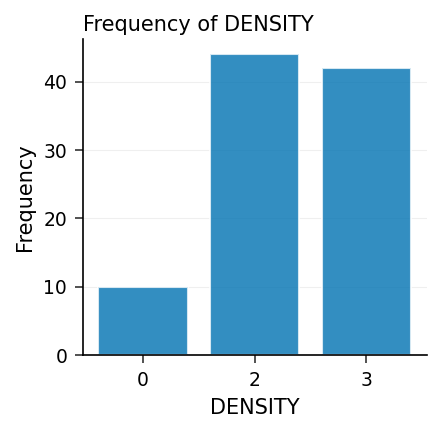

In [2]:
PROCEDURA GREDUCE DATI=zonemap out=reducedmap;
    id zone;
ESEGUIRE;

PROCEDURA FREQUENZE DATI=reducedmap;
    TABLES DENSITY / nocum;
    ETICHETTA DENSITY = "Livello di Densità";
    TITOLO "Punti di confine mantenuti per ogni livello di DENSITY";
ESEGUIRE;

## Passo 3 — Esaminare i livelli di densità

La tabella di frequenza mostra come GREDUCE ha classificato i 96 punti di confine:

| DENSITY | Punti | Quota |
|---------|--------|-------|
| 0 | 10 | 10,4% |
| 2 | 44 | 45,8% |
| 3 | 42 | 43,8% |

Solo 10 punti portano il livello più basso (le ancore della forma essenziale), mentre i restanti 86 si dividono tra i livelli 2 e 3. Per un livello dashboard manteniamo tutto a `DENSITY <= 2`: questo conserva 54 dei 96 punti, eliminando i 42 vertici di dettaglio più fine (`DENSITY=3`). La PROC MEANS seguente conferma che il livello grossolano contiene 13–14 vertici per zona invece dei 24 originali.

In [3]:
PROCEDURA MEDIE DATI=reducedmap n;
    CLASSE zone;
    DOVE DENSITY <= 2;
    VARIABILE x;
    ETICHETTA zone = "Zona"
          x    = "Coordinata X";
    TITOLO "Vertici mantenuti per zona a dettaglio dashboard (DENSITY <= 2)";
ESEGUIRE;

                            Vertici mantenuti per zona a dettaglio dashboard (DENSITY <= 2)                             

                                                  The MEANS Procedure

                                           Analysis Variable : X Coordinata X

        Zona              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 4 — Costruire la mappa grossolana e la risposta di performance per zona

Materializziamo il livello dashboard come `coarsemap` (`DENSITY <= 2`) in modo che PROC GMAP possa disegnare direttamente il contorno ridotto. Sintetizziamo anche una riga di KPI per zona — un **tasso di consegna puntuale** e un **volume giornaliero di pacchi** — con chiave su `zone` in modo che GMAP possa colorare ogni area.

In [4]:
DATI coarsemap;
    IMPOSTARE reducedmap;
    DOVE DENSITY <= 2;
ESEGUIRE;

DATI zonekpi;
    CHIAMARE streaminit(771);
    FARE zone = 1 FINO_A 4;
        /* tasso puntuale centrato vicino al 92%, dispersione realistica */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        USCITA;
    FINE;
    ETICHETTA zone        = "Zona"
          ontime_rate = "Tasso di Consegna Puntuale (%)"
          parcels     = "Volume Pacchi";
ESEGUIRE;

PROCEDURA STAMPARE DATI=zonekpi noobs;
    TITOLO "KPI di consegna sintetici per zona";
ESEGUIRE;

                                           KPI di consegna sintetici per zona                                           

zone  ontime_rate  parcels
   1         92.6     4704
   2         95.6     2932
   3         93.4     2934
   4         94.6     2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


I quattro tassi di consegna puntuale sintetici si collocano tra il 92,6% e il 95,6%, con volumi giornalieri di pacchi da circa 2.500 a 4.700. La zona 2 è la migliore con il 95,6%; la zona 1 è la più debole con il 92,6%. Questi sono i valori che le fasce di colore della coropletica codificano.

## Passo 5 — Generare le coropletiche a dettaglio completo e ridotto

Disegniamo la stessa coropletica di consegna puntuale due volte: una dal `reducedmap` completo a 96 vertici e una dal `coarsemap` a 54 vertici. `MAP=` fornisce i confini, `DATA=` la risposta KPI, ed entrambe condividono l'ID `zone`. L'istruzione `CHORO` riempie ogni zona in base a `ontime_rate` con fasce di colore `LEVELS=4` e `COUTLINE=` per bordi nitidi. Confrontare le due mappe mostra quanto costa visivamente la riduzione.

                                       Dettaglio completo: 96 vertici di confine                                        




NOTE: Option TITLE changed to Dettaglio completo: 96 vertici di confine.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Tasso di Consegna Puntuale (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


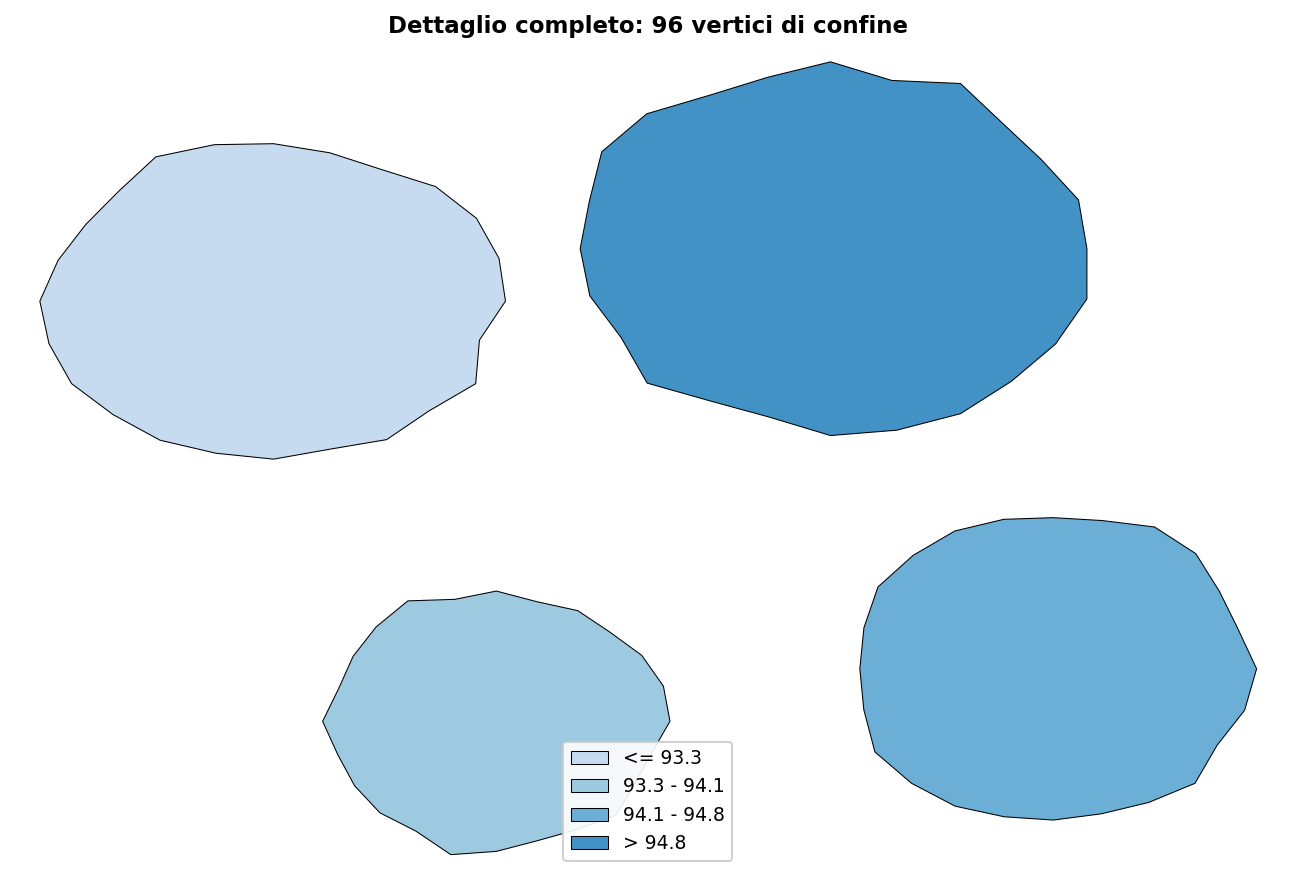

In [5]:
TITOLO "Dettaglio completo: 96 vertici di confine";
PROCEDURA GMAP map=reducedmap DATI=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
ESEGUIRE;

                                      Dettaglio ridotto: 54 vertici (DENSITY <= 2)                                      




NOTE: Option TITLE changed to Dettaglio ridotto: 54 vertici (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Tasso di Consegna Puntuale (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


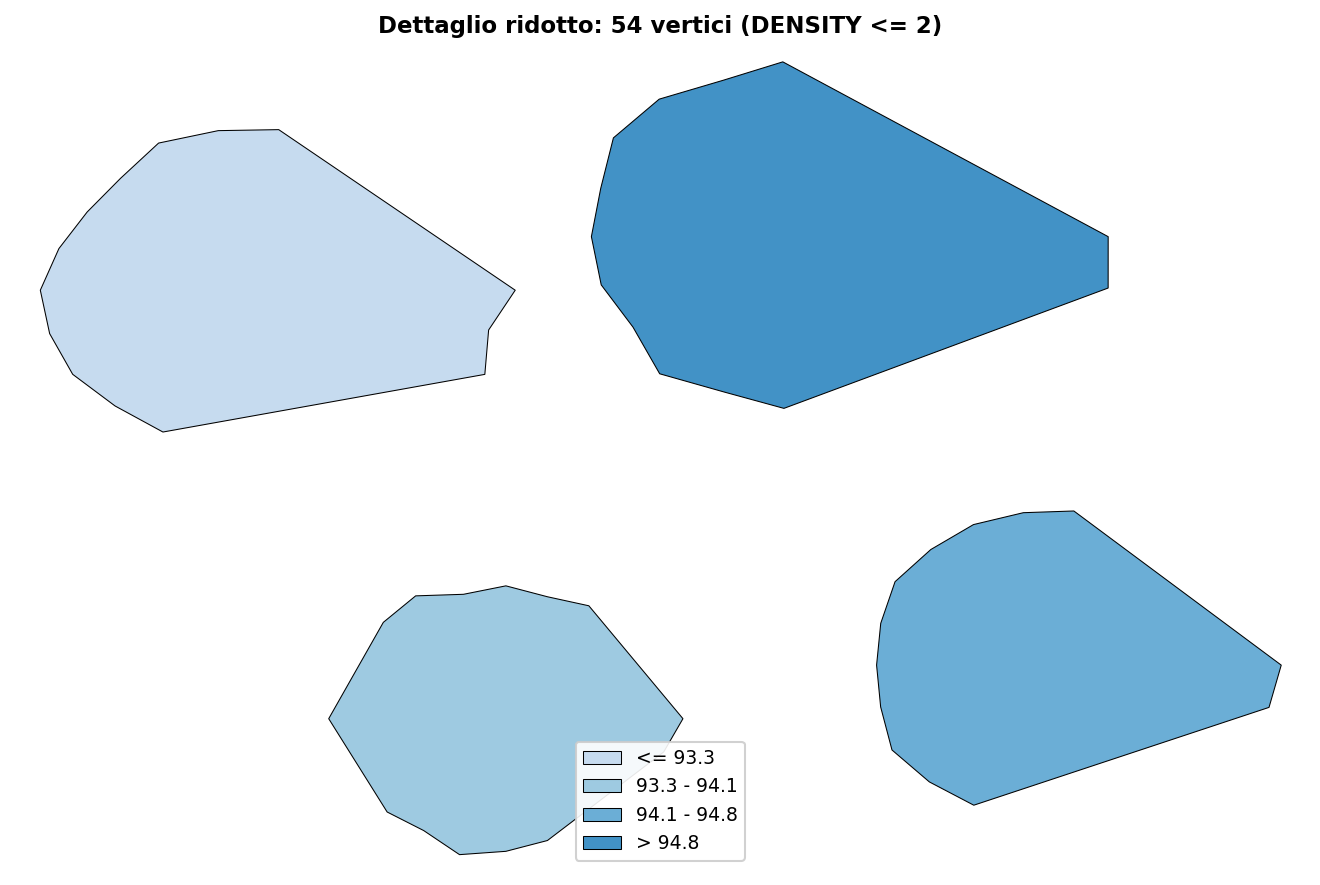

In [6]:
TITOLO "Dettaglio ridotto: 54 vertici (DENSITY <= 2)";
PROCEDURA GMAP map=coarsemap DATI=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
ESEGUIRE;

## Interpretazione dei risultati

PROC GREDUCE ha trasformato ogni contorno di zona a 24 vertici in un insieme graduato di punti di confine (livelli 0, 2 e 3 in questa esecuzione). Selezionare il livello `DENSITY <= 2` ha ridotto la mappa da 96 a 54 vertici — una riduzione del 44% dei punti che il renderer deve disegnare — eppure le coropletiche affiancate confermano che le quattro zone restano chiaramente riconoscibili: i contorni della mappa ridotta sono visibilmente più angolari, ma ogni territorio mantiene posizione, dimensione e fascia di colore, quindi un operatore legge lo stesso quadro riassuntivo in entrambi i casi.

Quel quadro riassuntivo classifica le zone per tasso di consegna puntuale: la zona 2 guida con il 95,6% (fascia più scura), le zone 3 e 4 si collocano a metà classifica intorno al 93–95%, e la zona 1 è ultima con il 92,6% (fascia più chiara) — il territorio che un pianificatore indagherebbe per primo per problemi di instradamento o capacità del deposito.

Poiché la riduzione non è distruttiva — i punti a dettaglio completo restano in `reducedmap` — lo stesso dataset supporta sia la vista dashboard veloce (`DENSITY <= 2`) sia una vista di stampa o audit ad alta risoluzione (`DENSITY <= 3`, o l'insieme completo) semplicemente cambiando una soglia `WHERE`, senza bisogno di reimportare o ridurre di nuovo la geometria.